In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('IPL.csv')
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


In [3]:
# basic Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [4]:
# check the size of rows and columns of the dataset
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


In [5]:
# now let's see how many columns have null value in total
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Text(0.5, 1.0, 'most match win by team')

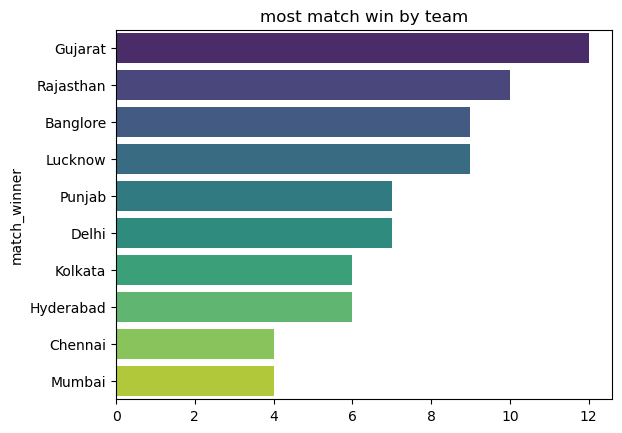

In [26]:
# now,here comes some basic questions
# which team won the most matches
match_wins=df['match_winner'].value_counts()
sns.barplot(y= match_wins.index,x= match_wins.values,palette="viridis")
plt.title("most match win by team")

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

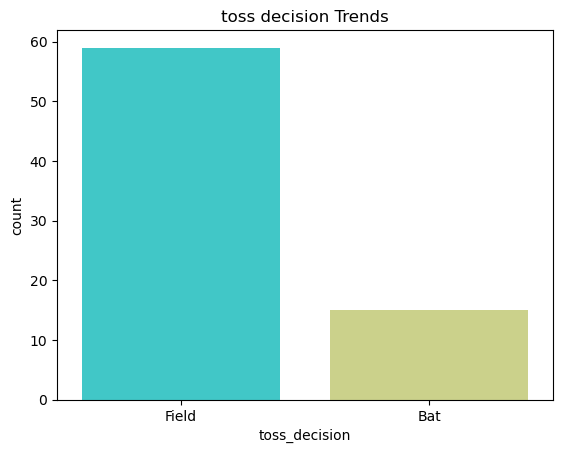

In [23]:
# Toss Decision Trends

sns.countplot(x=df['toss_decision'],palette="rainbow")
plt.title("toss decision Trends")


In [29]:
# Toss winner vs Match winner
df[df['toss_winner']==df['match_winner']]['match_id'].count()

np.int64(36)

In [30]:
# Toloss winner vs Match Looser
# **Percentage = (Part / Wh0le) × 100**
count=df[df['toss_winner']!=df['match_winner']]['match_id'].count()
percentage = (count/df.shape[0])*100
percentage.round(2)

np.float64(51.35)

Text(0.5, 1.0, 'wonby')

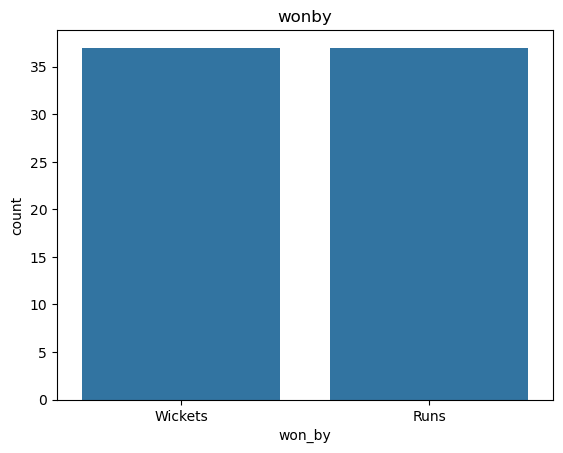

In [10]:
# how do teams win?
sns.countplot(x=df['won_by'])
plt.title("wonby")

Text(0.5, 1.0, 'Top 10 players ')

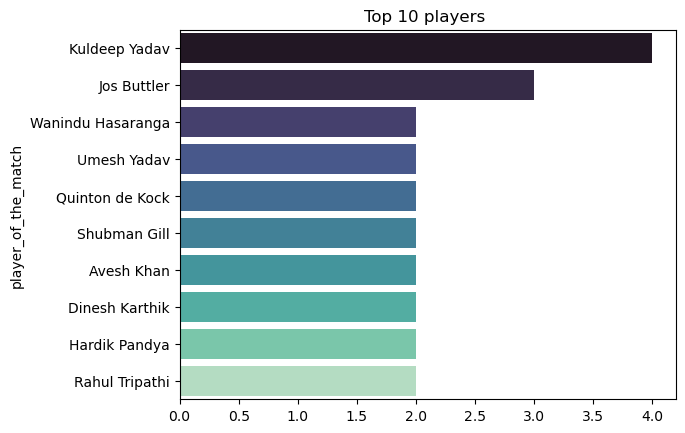

In [11]:
# KEY PLAYER PERFORMANCES
# most "player of  the match" Awards
count = df["player_of_the_match"].value_counts().head(10)
sns.barplot(x=count.values, y= count.index,palette="mako")
plt.title("Top 10 players ")

In [12]:
# Top Scorers
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head()

high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

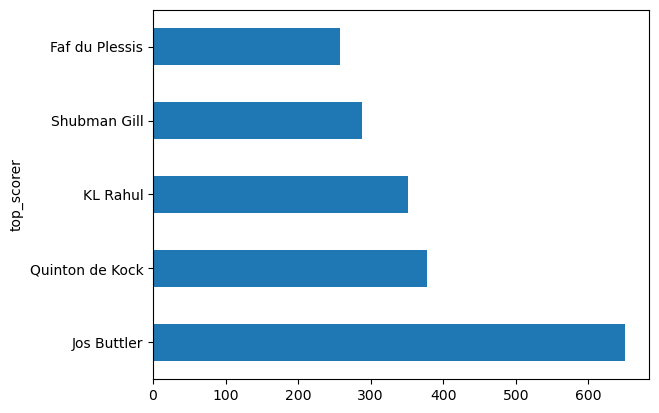

In [13]:
high.plot(kind="barh")

<Axes: ylabel='best_bowling'>

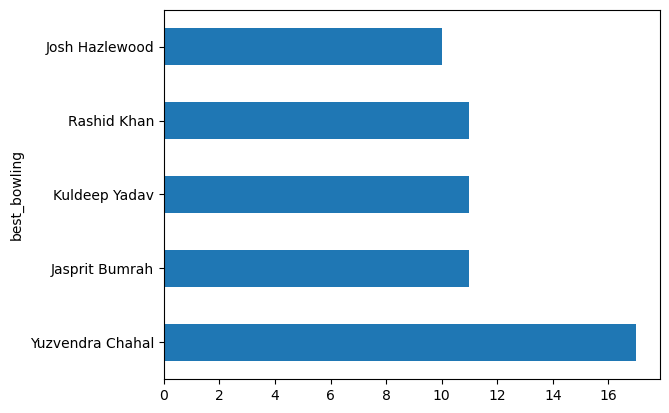

In [14]:
#  10 best bowling Figures
df['highest_wickets'] =df["best_bowling_figure"].apply(lambda x: x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head()
top_bowlers
top_bowlers.plot(kind="barh")

<Axes: ylabel='venue'>

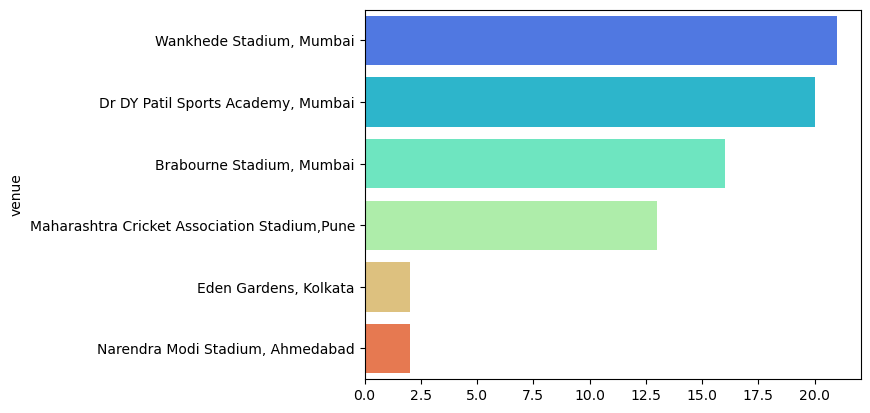

In [15]:
# CUSTOM QUESTION AND INSIGHTS
# most matches played by venue
venue_count =df['venue'].value_counts()
sns.barplot(y=venue_count.index,x=venue_count.values,palette='rainbow')

In [16]:
# who won the highest margin by runs?
df[df['won_by']== 'Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner',"margin"]]

,match_winner,margin
54,Chennai,91


In [17]:
# which player had the highest individual score?
df[df['highscore']== df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [18]:
# which bowler had the best bowling figures

df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
